In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd

In [ ]:
headers={"User-Agent": "Mozilla/5.0"}


### Part 1 — Web Scraping (Dataset Creation)

In this section, we scrape the **Top Anime** pages from *MyAnimeList* to build a dataset with at least **10,000 items**.

- We loop over the ranking pages with `limit` from 0 to 9950 (step 50), which covers 200 pages × 50 records ≈ 10,000 anime records.
- For each anime we extract:
  - `Title` – anime name.
  - `Score` – user rating on MyAnimeList.
  - `Type` – format (TV, Movie, OVA, ONA, etc.).
  - `Episodes` – number of episodes.
  - `Start_Date` and `End_Date` – airing period (or `Ongoing` / `N/A`).
  - `Members` – number of users who added the anime to their list.[file:28]

We then create a pandas DataFrame and export it to **`Anime_top_10000.csv`**, satisfying the requirement that the final dataset must be saved as a CSV file.


In [ ]:
import os

titles = []
scores = []
anime_type_list = []
episodes_list = []
start_date_list = []
end_date_list = []
members_list = []

for limit in range(0, 10000, 50):
    url = f"https://myanimelist.net/topanime.php?limit={limit}&ajax=1"
    print("Parsing:", url)

    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(r.text, "html.parser")

    rows = soup.find_all("tr", class_="ranking-list")

    if not rows:
        print("N/A:", limit)
        continue

    for row in rows:

        title = row.find("h3").text.strip()
        titles.append(title)

        score_tag = row.select_one("td.score span")
        scores.append(score_tag.text.strip() if score_tag else "N/A")

        info = row.find("div", class_="information")
        if info:
            lines = [l.strip() for l in info.text.split("\n") if l.strip()]
        else:
            lines = ["N/A", "N/A", "N/A"]

        # TYPE + EPISODES
        type_ep = lines[0] if len(lines) > 0 else "N/A"
        if "(" in type_ep:
            anime_type = type_ep.split("(")[0].strip()
            eps = type_ep.split("(")[1].replace("eps)", "").replace("ep)", "").strip()
        else:
            anime_type = type_ep
            eps = "N/A"
        anime_type_list.append(anime_type)
        episodes_list.append(eps)

        # AIR DATES
        date_line = lines[1] if len(lines) > 1 else "N/A"

        date_parts = [part.strip() for part in date_line.split(" - ")]

        current_start_date = "N/A"
        current_end_date = "N/A"

        if len(date_parts) == 2:
            current_start_date = date_parts[0]
            current_end_date = date_parts[1]
        elif len(date_parts) == 1:
            current_start_date = date_parts[0]
            current_end_date = "Ongoing"
        # If len(date_parts) is 0 or >2, they remain "N/A" as initialized

        start_date_list.append(current_start_date)
        end_date_list.append(current_end_date)

        # MEMBERS
        members_line = lines[2] if len(lines) > 2 else "N/A"
        members_list.append(members_line)

    time.sleep(1)

# CREATE DATAFRAME
df = pd.DataFrame({
    "Title": titles,
    "Score": scores,
    "Type": anime_type_list,
    "Episodes": episodes_list,
    "Start_Date": start_date_list,
    "End_Date": end_date_list,
    "Members": members_list
})

#  CSV
filename = "Anime_top_10000.csv"
df.to_csv(filename, index=False, encoding="utf-8-sig")
print("Ready ", len(df))


if os.path.exists(filename):
    print(f"CSV file found: {filename}. Loading data...")
    df = pd.read_csv(filename)
else:
    print("CSV file not found. Using the DataFrame just scraped.")

# first 5 and last 5
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- LAST 5 ROWS ---")
print(df.tail())

Parsing: https://myanimelist.net/topanime.php?limit=0&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=50&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=100&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=150&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=200&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=250&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=300&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=350&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=400&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=450&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=500&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=550&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=600&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=650&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=700&ajax=1
Parsing: https://myanimelist.net/topanime.php?limit=750&aj

### Part 2 — Data Inspection

Here we load the scraped CSV file `Anime_top_10000.csv` and perform initial inspection.

We:
- Use `df.head()`, `df.info()`, and `df.describe()` to understand the structure and basic statistics.
- Count missing values with `df.isnull().sum()`.
- Inspect data types to find wrong types (e.g. dates and numbers stored as strings).
- Detect and print duplicate rows using `df.duplicated()`.

This satisfies the requirement to show head/info/describe, missing values, wrong types, and duplicates.


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("Anime_top_10000.csv")
df

,Title,Score,Type,Episodes,Start_Date,End_Date,Members
0,Sousou no Frieren,9.29,TV,28,Sep 2023,Mar 2024,"1,270,262 members"
1,Chainsaw Man Movie: Reze-hen,9.18,Movie,1,Sep 2025,Sep 2025,"283,512 members"
2,Fullmetal Alchemist: Brotherhood,9.10,TV,64,Apr 2009,Jul 2010,"3,603,364 members"
3,Steins;Gate,9.07,TV,24,Apr 2011,Sep 2011,"2,756,137 members"
4,Shingeki no Kyojin Season 3 Part 2,9.05,TV,10,Apr 2019,Jul 2019,"2,520,958 members"
...,...,...,...,...,...,...,...
9995,Arifureta Shokugyou de Sekai Saikyou Picture D...,6.05,ONA,13,Jul 2019,Oct 2019,"3,513 members"
9996,Attack No.1: Namida no Sekai Senshuken,6.05,Movie,1,Dec 1970,Dec 1970,"1,155 members"
9997,"Boku, Otaryman.",6.05,OVA,1,Jan 2010,Jan 2010,"4,670 members"
9998,"Bye Bye, Earth",6.05,TV,10,Jul 2024,Sep 2024,"69,303 members"


In [ ]:
df.head()

,Title,Score,Type,Episodes,Start_Date,End_Date,Members
0,Sousou no Frieren,9.29,TV,28,Sep 2023,Mar 2024,"1,270,262 members"
1,Chainsaw Man Movie: Reze-hen,9.18,Movie,1,Sep 2025,Sep 2025,"283,512 members"
2,Fullmetal Alchemist: Brotherhood,9.10,TV,64,Apr 2009,Jul 2010,"3,603,364 members"
3,Steins;Gate,9.07,TV,24,Apr 2011,Sep 2011,"2,756,137 members"
4,Shingeki no Kyojin Season 3 Part 2,9.05,TV,10,Apr 2019,Jul 2019,"2,520,958 members"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       10000 non-null  object 
 1   Score       10000 non-null  float64
 2   Type        10000 non-null  object 
 3   Episodes    10000 non-null  object 
 4   Start_Date  10000 non-null  object 
 5   End_Date    10000 non-null  object 
 6   Members     10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB


In [ ]:
df.describe()

,Score
count,10000.000000
mean,6.980518
std,0.619485
min,6.050000
25%,6.470000
50%,6.900000
75%,7.390000
max,9.290000


In [ ]:
#  missing values problem
print(df.isnull().sum())

Title         0
Score         0
Type          0
Episodes      0
Start_Date    0
End_Date      0
Members       0
dtype: int64


In [ ]:
# Wrong value problem
print(df.dtypes)
# Start_date, End_date, Episodes, (members) wrong types

Title          object
Score         float64
Type           object
Episodes       object
Start_Date     object
End_Date       object
Members        object
dtype: object


In [ ]:
# Duplicates problem
print("\n=== Дубликаты ===")
print("Количество дубликатов:", df.duplicated().sum())
duplicates = df[df.duplicated()]
print(duplicates)


=== Дубликаты ===
Количество дубликатов: 0
Empty DataFrame
Columns: [Title, Score, Type, Episodes, Start_Date, End_Date, Members]
Index: []


### Part 2 — Data Cleaning & Feature Engineering

In this step we clean data types, handle missing values, remove outliers, and create new features.

**1. Fixing data types**
- Convert `Episodes` to numeric (turning `'?'` into `NaN`).
- Clean `Members` by removing commas and `' members'`, then convert to `float`.
- Parse `Start_Date` and `End_Date` as `datetime`.

**2. Cleaning text fields**
- Define `clean_text` to strip spaces, lowercase titles, remove HTML tags, and normalize whitespace, then apply it to `Title`.

**3. Handling missing values**
- Create `df_clean = df.copy()`.
- Fill missing `Score` with the mean score.
- Fill missing `Episodes` with 12 (typical one‑cour length).
- Replace missing `End_Date` with today’s date.

**4. Removing outliers**
- Use the IQR rule on `Members` to remove extreme popularity outliers.

**5. Creating derived features**
- `Duration_months` – months between `Start_Date` and `End_Date`.
- `Score_group` – categorical rating groups: Low / Medium / High / Top.

Finally, we save the cleaned dataset to `Anime_top_10000_clean.csv` for further analysis.


In [ ]:
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")  # '?' станет NaN
print("\nПропуски после конвертации Episodes в число:")
print(df["Episodes"].isnull().sum())

df["Members"] = df["Members"].str.replace(',', '').str.replace(' members', '').astype(float)

df.loc[:, 'Start_Date'] = pd.to_datetime(df['Start_Date'], format='%b %Y', errors='coerce')
df.loc[:, 'End_Date']   = pd.to_datetime(df['End_Date'],   format='%b %Y', errors='coerce') # а здесь ongoig or sep - станут NaT


Пропуски после конвертации Episodes в число:
48


In [ ]:
from bs4 import BeautifulSoup

def clean_text(text):
    if pd.isna(text): # если значение в ячейке пустое (NaN), функция сразу возвращает его, чтобы не ломать обработку
        return text
    text = text.strip().lower()               # пробелы + нижний регистр
    text = BeautifulSoup(text, "lxml").get_text()  # удалить HTML
    text = text.replace('\n', ' ').replace('\t', ' ').replace('  ', ' ') # удаляет перенос строки и табуляцию если они есть но в целом их нету
    return text

df['Title'] = df['Title'].apply(clean_text)


In [ ]:
df_clean = df.copy()

# --- 1. Приводим числовые поля к числу ---

# Score: заполняем пропуски средним
df_clean['Score'] = df_clean['Score'].fillna(df_clean['Score'].mean())

# Members: НИЧЕГО не трогаем строковыми методами, просто убедимся, что это число
df_clean['Members'] = pd.to_numeric(df_clean['Members'], errors='coerce')

# Episodes: переводим в число, нечисловые → NaN → заменяем на 12
df_clean['Episodes'] = pd.to_numeric(df_clean['Episodes'], errors='coerce').fillna(12)


In [ ]:
Q1 = df['Members'].quantile(0.25)
Q3 = df['Members'].quantile(0.75)
IQR = Q3 - Q1 # this is Inter quartile range

df = df[(df['Members'] >= Q1 - 1.5*IQR) & (df['Members'] <= Q3 + 1.5*IQR)]

In [ ]:
df_clean['Start_Date'] = pd.to_datetime(df_clean['Start_Date'], format='%b %Y', errors='coerce')
df_clean['End_Date']   = pd.to_datetime(df_clean['End_Date'], format='%b %Y', errors='coerce')


# Вывести строки с некорректными датами
invalid_start = df[df['Start_Date'].isna()]
invalid_end = df[df['End_Date'].isna()]

print("Некорректные Start_Date:")
print(invalid_start[['Title', 'Start_Date']])

print("\nНекорректные End_Date:")
print(invalid_end[['Title', 'End_Date']])

Некорректные Start_Date:
                                  Title Start_Date
5                    kingdom 6th season        NaT
166                            chiikawa        NaT
181           tian guan cifu short film        NaT
187           doupo cangqiong: nian fan        NaT
198                             xian ni        NaT
...                                 ...        ...
9840       ibarahime mata wa nemurihime        NaT
9876  maze☆bakunetsu jikuu: hot springs        NaT
9910           doraemon eigo kyoushitsu        NaT
9932                    haru wo irodoru        NaT
9939                           kokoroya        NaT

[195 rows x 2 columns]

Некорректные End_Date:
                                  Title End_Date
5                    kingdom 6th season      NaT
166                            chiikawa      NaT
181           tian guan cifu short film      NaT
187           doupo cangqiong: nian fan      NaT
198                             xian ni      NaT
...                  

In [ ]:
today = pd.Timestamp.today()
df_clean.loc[df_clean['End_Date'].isna(), 'End_Date'] = today

In [ ]:
# Длительность аниме в месяцах (если обе даты известны)
df_clean['Duration_months'] = (
    (df_clean['End_Date'].dt.year - df_clean['Start_Date'].dt.year) * 12 +
    (df_clean['End_Date'].dt.month - df_clean['Start_Date'].dt.month)
)

# Категория по Score
df_clean['Score_group'] = pd.cut(
    df_clean['Score'],
    bins=[0, 7, 8, 9, 10],
    labels=['Low', 'Medium', 'High', 'Top']
)
df_clean

,Title,Score,Type,Episodes,Start_Date,End_Date,Members,Duration_months,Score_group
0,sousou no frieren,9.29,TV,28.0,2023-09-01,2024-03-01,1270262.0,6.0,Top
1,chainsaw man movie: reze-hen,9.18,Movie,1.0,2025-09-01,2025-09-01,283512.0,0.0,Top
2,fullmetal alchemist: brotherhood,9.10,TV,64.0,2009-04-01,2010-07-01,3603364.0,15.0,Top
3,steins;gate,9.07,TV,24.0,2011-04-01,2011-09-01,2756137.0,5.0,Top
4,shingeki no kyojin season 3 part 2,9.05,TV,10.0,2019-04-01,2019-07-01,2520958.0,3.0,Top
...,...,...,...,...,...,...,...,...,...
9995,arifureta shokugyou de sekai saikyou picture d...,6.05,ONA,13.0,2019-07-01,2019-10-01,3513.0,3.0,Low
9996,attack no.1: namida no sekai senshuken,6.05,Movie,1.0,1970-12-01,1970-12-01,1155.0,0.0,Low
9997,"boku, otaryman.",6.05,OVA,1.0,2010-01-01,2010-01-01,4670.0,0.0,Low
9998,"bye bye, earth",6.05,TV,10.0,2024-07-01,2024-09-01,69303.0,2.0,Low


In [ ]:
df_clean.to_csv("Anime_top_10000_clean.csv", index=False, encoding="utf-8-sig")
print("Cleaned dataset saved to Anime_top_10000_clean.csv")



Cleaned dataset saved to Anime_top_10000_clean.csv


### Part 3 — Exploratory Data Analysis (EDA)

Now we explore the cleaned dataset `df_clean`.

- First we compute descriptive statistics for `Score`, `Episodes`, `Members`, and `Duration_months`.
- Then we create multiple visualizations:
  1. Score distribution.
  2. Episodes distribution.
  3. Type distribution (bar chart).
  4. Average Score by Type.
  5. Score vs Members (regression).
  6. Score vs Episodes (scatter).
  7. Score by Score_group (boxplot).
  8. Score by Episode group (violin plot).
  9. Correlation heatmap.




=== DESCRIPTIVE STATISTICS ===
              Score      Episodes       Members  Duration_months
count  10000.000000  10000.000000  1.000000e+04      9803.000000
mean       6.980518     15.629800  1.075777e+05         4.266347
std        0.619485     41.409572  2.734202e+05        12.970269
min        6.050000      1.000000  2.260000e+02         0.000000
25%        6.470000      1.000000  4.276750e+03         0.000000
50%        6.900000     11.000000  1.820250e+04         2.000000
75%        7.390000     13.000000  8.474000e+04         5.000000
max        9.290000   1787.000000  4.263026e+06       518.000000

=== TYPE COUNTS ===
Type
TV            4331
Movie         1722
ONA           1338
OVA           1173
Special       1003
TV Special     433
Name: count, dtype: int64

=== SCORE GROUP COUNTS ===
Score_group
Low       5477
Medium    3830
High       680
Top         13
Name: count, dtype: int64


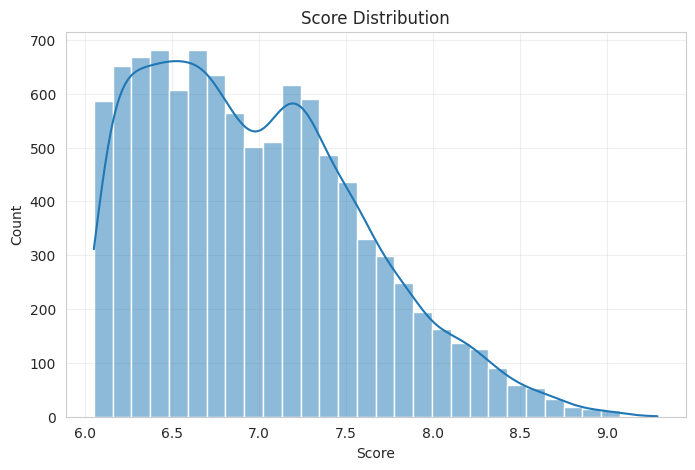

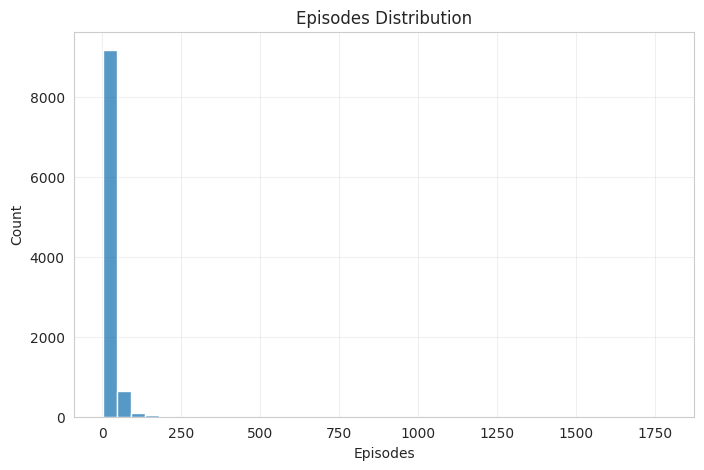

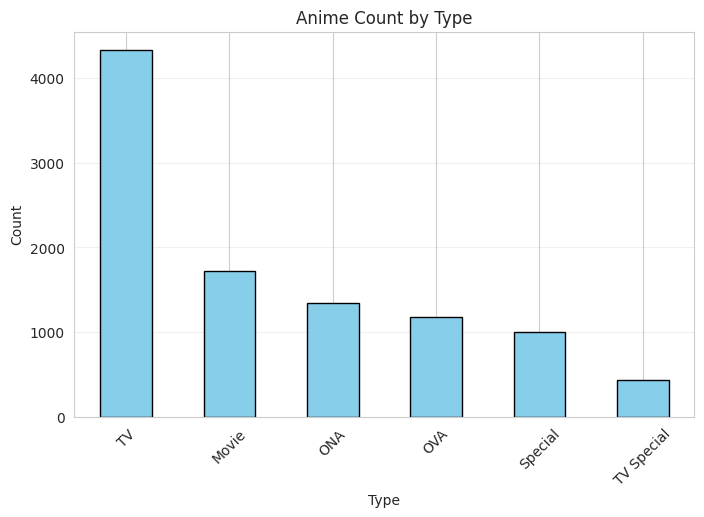

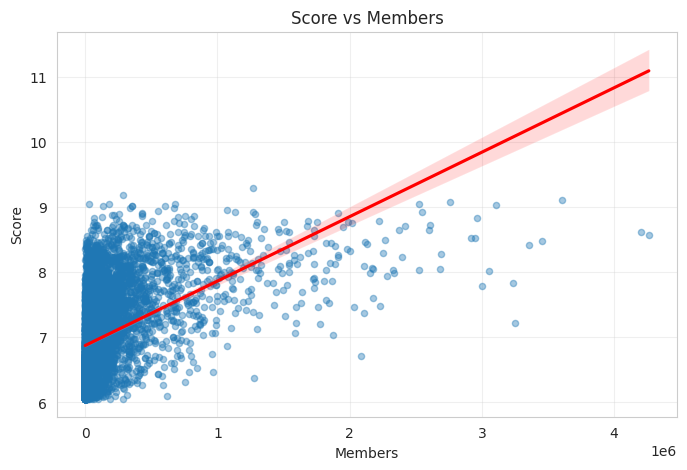

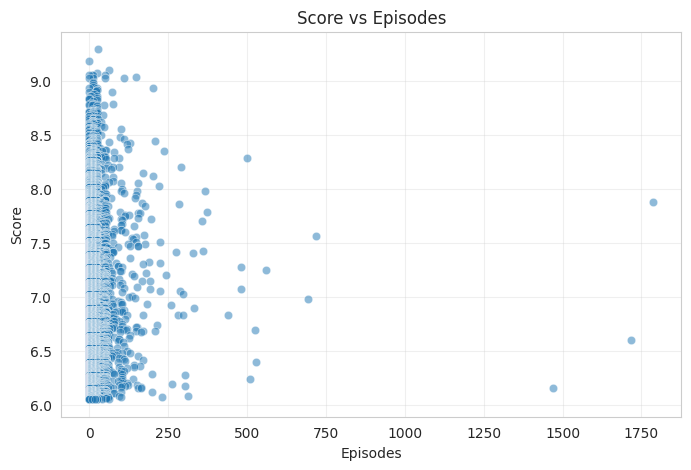

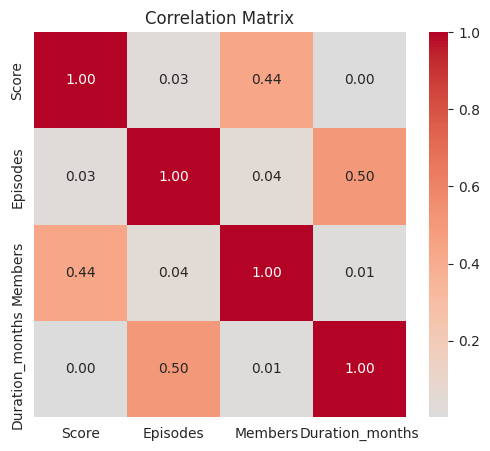

In [ ]:
# ===================== PART 3 — EDA =====================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df_clean[['Score', 'Episodes', 'Members', 'Duration_months']].describe())

print("\n=== TYPE COUNTS ===")
print(df_clean['Type'].value_counts())

print("\n=== SCORE GROUP COUNTS ===")
print(df_clean['Score_group'].value_counts())

# 1) Распределение Score
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Score'], bins=30, kde=True)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

# 2) Распределение Episodes
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Episodes'], bins=40, kde=False)
plt.title('Episodes Distribution')
plt.xlabel('Episodes')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

# 3) Кол-во аниме по типу (TV/Movie/OVA/…)
plt.figure(figsize=(8, 5))
df_clean['Type'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Anime Count by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# 4) Зависимость Score от Members (регрессионный график)
plt.figure(figsize=(8, 5))
sns.regplot(data=df_clean, x='Members', y='Score',
            scatter_kws={'alpha': 0.4, 's': 20},
            line_kws={'color': 'red'})
plt.title('Score vs Members')
plt.xlabel('Members')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()

# 5) Зависимость Score от Episodes (scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Episodes', y='Score', alpha=0.5)
plt.title('Score vs Episodes')
plt.xlabel('Episodes')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()

# 6) Корреляционная матрица
plt.figure(figsize=(6, 5))
corr = df_clean[['Score', 'Episodes', 'Members', 'Duration_months']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


Loading data from existing CSV file: 'Anime_top_10000.csv'


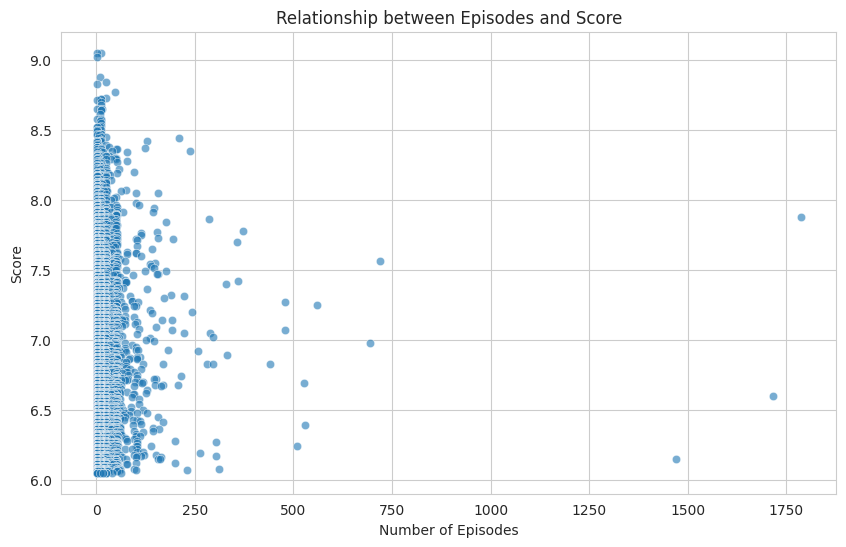

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import time
import os

# ---------- 1. Загрузка / минимальный скрапинг ----------

filename = "Anime_top_10000.csv"

if os.path.exists(filename):
    print(f"Loading data from existing CSV file: '{filename}'")
    df = pd.read_csv(filename)
else:
    print(f"CSV file '{filename}' not found. Performing minimal scraping to generate data.")
    titles = []
    scores = []
    anime_type_list = []
    episodes_list = []
    start_date_list = []
    end_date_list = []
    members_list = []
    headers = {"User-Agent": "Mozilla/5.0"}

    # Для примера — только первые 50 записей
    for limit in range(0, 50, 50):  # 0..49
        url = f"https://myanimelist.net/topanime.php?limit={limit}&ajax=1"
        r = requests.get(url, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")
        rows = soup.find_all("tr", class_="ranking-list")

        if not rows:
            print("No data rows found during minimal scrape. Exiting scraping process.")
            break

        for row in rows:
            # Title
            title = row.find("h3").text.strip()
            titles.append(title)

            # Score
            score_tag = row.select_one("td.score span")
            scores.append(score_tag.text.strip() if score_tag else "N/A")

            # Info block
            info = row.find("div", class_="information")
            if info:
                lines = [l.strip() for l in info.text.split("\n") if l.strip()]
            else:
                lines = ["N/A", "N/A", "N/A"]

            # Type & Episodes
            type_ep = lines[0] if len(lines) > 0 else "N/A"
            if "(" in type_ep:
                anime_type = type_ep.split("(")[0].strip()
                eps = (
                    type_ep.split("(")[1]
                    .replace("eps)", "")
                    .replace("ep)", "")
                    .strip()
                )
            else:
                anime_type = type_ep
                eps = "N/A"
            anime_type_list.append(anime_type)
            episodes_list.append(eps)

            # Dates
            date_line = lines[1] if len(lines) > 1 else "N/A"
            date_parts = [part.strip() for part in date_line.split(" - ")]
            current_start_date = "N/A"
            current_end_date = "N/A"
            if len(date_parts) == 2:
                current_start_date = date_parts[0]
                current_end_date = date_parts[1]
            elif len(date_parts) == 1:
                current_start_date = date_parts[0]
                current_end_date = "Ongoing"
            start_date_list.append(current_start_date)
            end_date_list.append(current_end_date)

            # Members (строка вида "1,234,567 members")
            members_line = lines[2] if len(lines) > 2 else "N/A"
            members_list.append(members_line)

    df = pd.DataFrame(
        {
            "Title": titles,
            "Score": scores,
            "Type": anime_type_list,
            "Episodes": episodes_list,
            "Start_Date": start_date_list,
            "End_Date": end_date_list,
            "Members": members_list,
        }
    )
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Minimal data scraped and saved ({len(df)} records) to '{filename}'.")

# ---------- 2. Базовая очистка исходного df ----------

# Score → число
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# Episodes → число
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")

# Members: надёжная цепочка приведения к числу
df["Members"] = (
    df["Members"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" members", "", regex=False)
)
df["Members"] = pd.to_numeric(df["Members"], errors="coerce")

# Даты
df["Start_Date"] = pd.to_datetime(df["Start_Date"], format="%b %Y", errors="coerce")
df["End_Date"] = pd.to_datetime(df["End_Date"], format="%b %Y", errors="coerce")

# Очистка текста в Title
def clean_text(text):
    if pd.isna(text):
        return text
    text = text.strip().lower()
    text = BeautifulSoup(text, "lxml").get_text()
    text = text.replace("\n", " ").replace("\t", " ").replace("  ", " ")
    return text

df["Title"] = df["Title"].apply(clean_text)

# Удаление выбросов по Members (IQR)
Q1 = df["Members"].quantile(0.25)
Q3 = df["Members"].quantile(0.75)
IQR = Q3 - Q1
df = df[
    (df["Members"] >= Q1 - 1.5 * IQR)
    & (df["Members"] <= Q3 + 1.5 * IQR)
]

# ---------- 3. df_clean: заполнение пропусков + новые признаки ----------

df_clean = df.copy()

# Score: заполнить средним
df_clean["Score"] = df_clean["Score"].fillna(df_clean["Score"].mean())

# Episodes: NaN → 12
df_clean["Episodes"] = df_clean["Episodes"].fillna(12)

# Заполнить End_Date сегодняшней датой, если пусто
today = pd.Timestamp.today()
df_clean.loc[df_clean["End_Date"].isna(), "End_Date"] = today

# Duration_months
df_clean["Duration_months"] = (
    (df_clean["End_Date"].dt.year - df_clean["Start_Date"].dt.year) * 12
    + (df_clean["End_Date"].dt.month - df_clean["Start_Date"].dt.month)
)

# Категории по Score
df_clean["Score_group"] = pd.cut(
    df_clean["Score"],
    bins=[0, 7, 8, 9, 10],
    labels=["Low", "Medium", "High", "Top"],
)

# ---------- 4. Scatter: Episodes vs Score ----------

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="Episodes", y="Score", alpha=0.6)

plt.xlabel("Number of Episodes")
plt.ylabel("Score")
plt.title("Relationship between Episodes and Score")
plt.grid(True)
plt.show()


Loading data from existing CSV file: 'Anime_top_10000.csv'


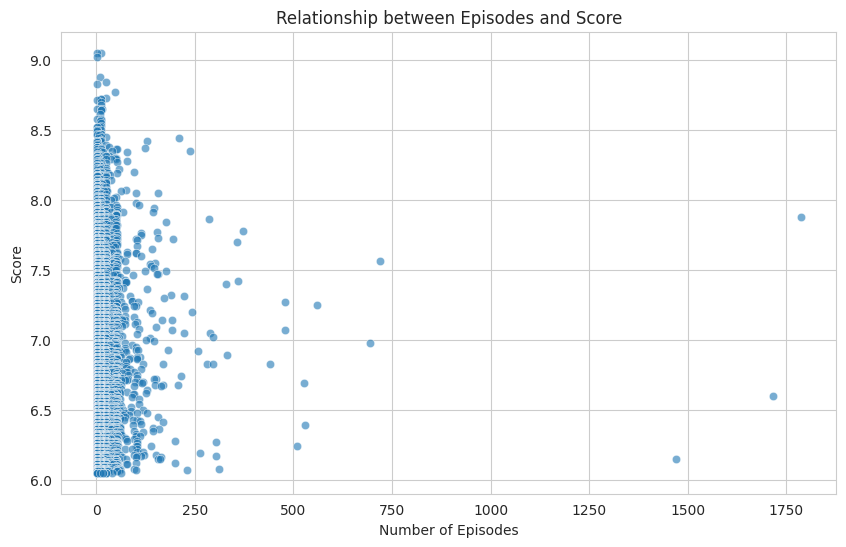

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import time
import os

# Define the filename for the scraped data
filename = "Anime_top_10000.csv"

# Check if the CSV file exists. If not, perform the full scrape to create it.
if os.path.exists(filename):
    print(f"Loading data from existing CSV file: '{filename}'")
    df = pd.read_csv(filename)
else:
    print(f"CSV file '{filename}' not found. Performing full scraping to generate data.")
    titles = []
    scores = []
    anime_type_list = []
    episodes_list = []
    start_date_list = []
    end_date_list = []
    members_list = []
    headers = {"User-Agent": "Mozilla/5.0"}

    # Perform the full scrape (up to 10000 entries)
    for limit in range(0, 10000, 50):
        url = f"https://myanimelist.net/topanime.php?limit={limit}&ajax=1"
        r = requests.get(url, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")
        rows = soup.find_all("tr", class_="ranking-list")

        if not rows:
            print(f"No data rows found at limit {limit}. Stopping scrape.")
            break

        for row in rows:
            title = row.find("h3").text.strip()
            titles.append(title)
            score_tag = row.select_one("td.score span")
            scores.append(score_tag.text.strip() if score_tag else "N/A")
            info = row.find("div", class_="information")
            if info:
                lines = [l.strip() for l in info.text.split("\n") if l.strip()]
            else:
                lines = ["N/A", "N/A", "N/A"]

            type_ep = lines[0] if len(lines) > 0 else "N/A"
            if "(" in type_ep:
                anime_type = type_ep.split("(")[0].strip()
                eps = type_ep.split("(")[1].replace("eps)", "").replace("ep)", "").strip()
            else:
                anime_type = type_ep
                eps = "N/A"
            anime_type_list.append(anime_type)
            episodes_list.append(eps)

            date_line = lines[1] if len(lines) > 1 else "N/A"
            date_parts = [part.strip() for part in date_line.split(" - ")]
            current_start_date = "N/A"
            current_end_date = "N/A"
            if len(date_parts) == 2:
                current_start_date = date_parts[0]
                current_end_date = date_parts[1]
            elif len(date_parts) == 1:
                current_start_date = date_parts[0]
                current_end_date = "Ongoing"
            start_date_list.append(current_start_date)
            end_date_list.append(current_end_date)

            members_line = lines[2] if len(lines) > 2 else "N/A"
            members_list.append(members_line)

        time.sleep(1) # Be respectful to the server

    df = pd.DataFrame({
        "Title": titles,
        "Score": scores,
        "Type": anime_type_list,
        "Episodes": episodes_list,
        "Start_Date": start_date_list,
        "End_Date": end_date_list,
        "Members": members_list
    })
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Full data scraped and saved ({len(df)} records) to '{filename}'.")

# --- Cleaning and Feature Engineering (as per original notebook steps) ---

# Convert 'Score' to numeric early
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

# Apply initial cleaning and type conversions to df
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")
df["Members"] = df["Members"].astype(str).str.replace(',', '').str.replace(' members', '').astype(float)
df.loc[:, 'Start_Date'] = pd.to_datetime(df['Start_Date'], format='%b %Y', errors='coerce')
df.loc[:, 'End_Date'] = pd.to_datetime(df['End_Date'], format='%b %Y', errors='coerce')

def clean_text(text):
    if pd.isna(text):
        return text
    text = text.strip().lower()
    text = BeautifulSoup(text, "lxml").get_text()
    text = text.replace('\n', ' ').replace('\t', ' ').replace('  ', ' ')
    return text
df['Title'] = df['Title'].apply(clean_text)

# Handle outliers in 'Members'
Q1 = df['Members'].quantile(0.25)
Q3 = df['Members'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Members'] >= Q1 - 1.5*IQR) & (df['Members'] <= Q3 + 1.5*IQR)]

# Create df_clean and apply further cleaning/feature engineering
df_clean = df.copy()

df_clean['Score'] = df_clean['Score'].fillna(df_clean['Score'].mean())
# Fill missing 'Episodes' (NaNs from '?' conversion) with 12
df_clean['Episodes'] = df_clean['Episodes'].fillna(12)

# Ensure 'Start_Date' and 'End_Date' are datetime objects in df_clean
df_clean['Start_Date'] = pd.to_datetime(df_clean['Start_Date'], errors='coerce')
df_clean['End_Date'] = pd.to_datetime(df_clean['End_Date'], errors='coerce')

# Fill missing 'End_Date' with today's date
today = pd.Timestamp.today()
df_clean.loc[df_clean['End_Date'].isna(), 'End_Date'] = today

# Calculate 'Duration_months'
df_clean['Duration_months'] = (
    (df_clean['End_Date'].dt.year - df_clean['Start_Date'].dt.year) * 12 +
    (df_clean['End_Date'].dt.month - df_clean['Start_Date'].dt.month)
)

# Create 'Score_group' category
df_clean['Score_group'] = pd.cut(
    df_clean['Score'],
    bins=[0, 7, 8, 9, 10],
    labels=['Low', 'Medium', 'High', 'Top']
)

# --- Create the scatter plot (this is the original plot from e75be918) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Episodes', y='Score', alpha=0.6)

plt.xlabel('Number of Episodes')
plt.ylabel('Score')
plt.title('Relationship between Episodes and Score')

plt.grid(True)
plt.show()

/tmp/ipython-input-2710106235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Type', order=df_clean['Type'].value_counts().index, palette='viridis')


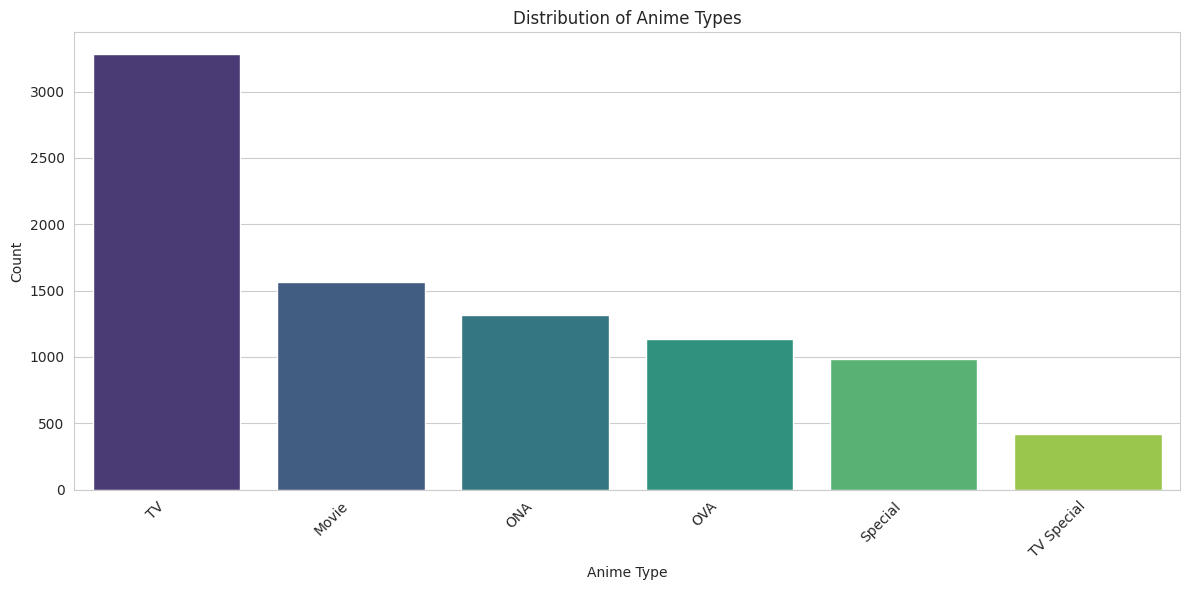

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for the distribution of 'Type'
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='Type', order=df_clean['Type'].value_counts().index, palette='viridis')

# Add labels and title
plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types')

# Rotate x-axis labels if they overlap
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

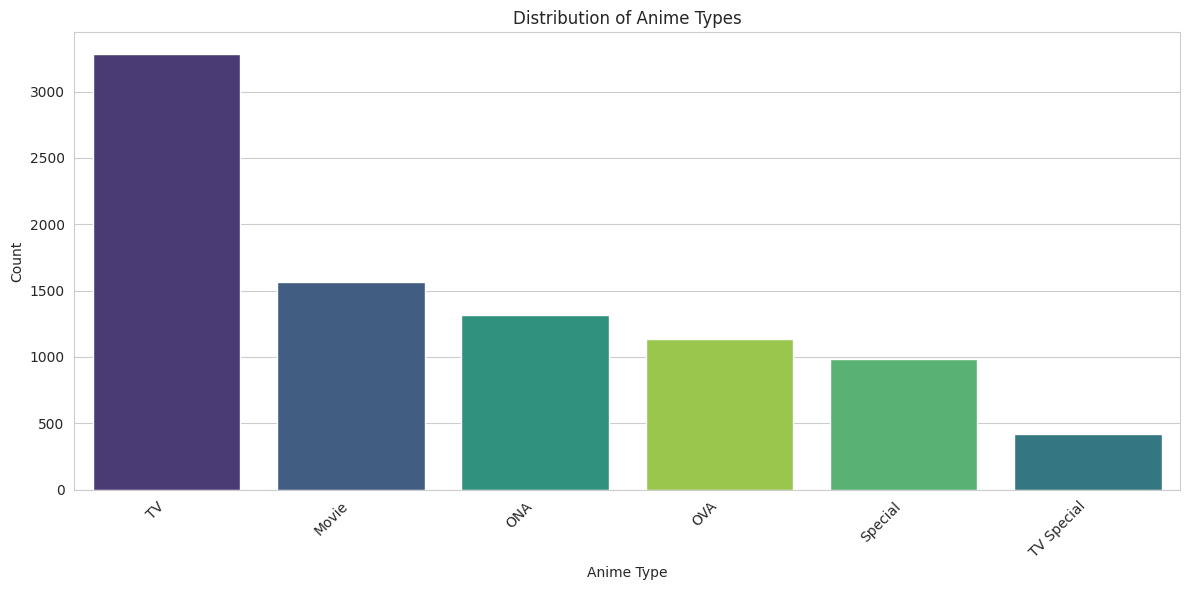

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for the distribution of 'Type'
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='Type', order=df_clean['Type'].value_counts().index, palette='viridis', hue='Type', legend=False)

# Add labels and title
plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types')

# Rotate x-axis labels if they overlap
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

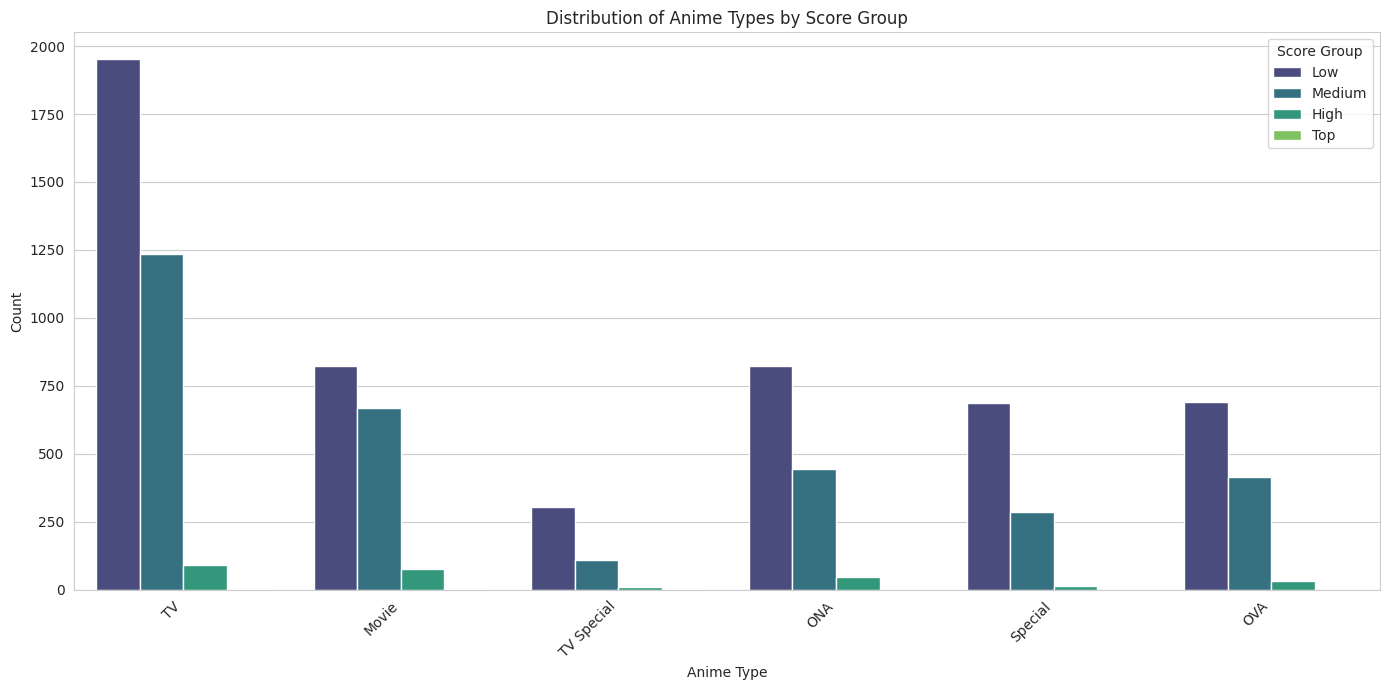

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grouped bar chart to show the distribution of anime types by score group
plt.figure(figsize=(14, 7))
sns.countplot(data=df_clean, x='Type', hue='Score_group', palette='viridis')

# Add labels and title
plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.title('Distribution of Anime Types by Score Group')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a legend
plt.legend(title='Score Group')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### Part 3 — Analytical Questions

Here we answer at least **8 analytical questions** about our dataset using `df_clean`:

1. Top‑10 anime by `Score`.
2. Top‑10 anime by `Members`.
3. Which types dominate the dataset (counts and percentages)?
4. Average `Score` and `Members` by `Type`.
5. Correlation between `Score` and `Members`.
6. Does longer `Duration_months` mean higher score?
7. Which anime are strong both in score and members (combined rank)?
8. How do `Score_group` categories differ in average score and members?




In [ ]:
print("\n=== ANALYTICAL QUESTIONS ===")

# Q1: Топ-10 аниме по Score
print("\nQ1: TOP 10 by Score")
top10_score = df_clean.nlargest(10, 'Score')[['Title', 'Score', 'Type', 'Episodes', 'Members']]
print(top10_score.to_string(index=False))

# Q2: Топ-10 самых популярных по Members
print("\nQ2: TOP 10 by Members")
top10_members = df_clean.nlargest(10, 'Members')[['Title', 'Members', 'Score', 'Type']]
print(top10_members.to_string(index=False))

# Q3: Какие типы (Type) доминируют в датасете?
print("\nQ3: Type distribution (count and percentage)")
type_counts = df_clean['Type'].value_counts()
type_pct = (type_counts / len(df_clean) * 100).round(2)
print(pd.DataFrame({'Count': type_counts, 'Percent': type_pct}))

# Q4: Средний Score и Members по типу
print("\nQ4: Average Score and Members by Type")
type_stats = df_clean.groupby('Type')[['Score', 'Members']].agg(['mean', 'median', 'count']).round(2)
print(type_stats)

# Q5: Есть ли связь между Score и Members?
print("\nQ5: Correlation between Score and Members")
corr_sm = df_clean['Score'].corr(df_clean['Members'])
print(f"Pearson r = {corr_sm:.4f}")

# Q6: Зависимость Score от длины (Duration_months)
print("\nQ6: Does longer duration mean higher score?")
dur_groups = df_clean.groupby(pd.cut(df_clean['Duration_months'], bins=[-1, 0, 6, 12, 36, 120],
                                     labels=['0', '1-6', '7-12', '13-36', '37+']))['Score'].mean().round(2)
print(dur_groups)

# Q7: Какие аниме с самым высоким Score при большом числе участников (Members)?
print("\nQ7: High Score & High Members (top 10 by combined rank)")
df_clean['Score_rank'] = df_clean['Score'].rank(ascending=False)
df_clean['Members_rank'] = df_clean['Members'].rank(ascending=False)
df_clean['Combined_rank'] = df_clean['Score_rank'] + df_clean['Members_rank']
top10_combined = df_clean.nsmallest(10, 'Combined_rank')[['Title', 'Score', 'Members', 'Type']]
print(top10_combined.to_string(index=False))

# Q8: Как распределяется Score по группам Score_group?
print("\nQ8: Score_group distribution and mean Members")
sg_stats = df_clean.groupby('Score_group')[['Score', 'Members']].agg(['mean', 'count']).round(2)
print(sg_stats)



=== ANALYTICAL QUESTIONS ===

Q1: TOP 10 by Score
                                                   Title  Score       Type  Episodes  Members
                                      kingdom 6th season   9.05         TV      12.0  25769.0
                                      gintama: the final   9.05      Movie       1.0 177162.0
                                    one piece fan letter   9.02 TV Special       1.0 135294.0
                     boku no hero academia: final season   8.88         TV      11.0 202328.0
                                      kingdom 3rd season   8.84         TV      26.0 127192.0
shingeki no kyojin movie: kanketsu-hen - the last attack   8.83      Movie       1.0  69493.0
                                         ashita no joe 2   8.77         TV      47.0  64680.0
                                      kingdom 4th season   8.73         TV      26.0  84769.0
                                      kingdom 5th season   8.72         TV      13.0  56814.0
         

/tmp/ipython-input-1285588313.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dur_groups = df_clean.groupby(pd.cut(df_clean['Duration_months'], bins=[-1, 0, 6, 12, 36, 120],
/tmp/ipython-input-1285588313.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sg_stats = df_clean.groupby('Score_group')[['Score', 'Members']].agg(['mean', 'count']).round(2)


### Optional Deep‑Dive Analysis (for report / appendix)

Here we define helper functions for deeper analysis that can be used in the written report or appendix:

- Yearly mean score over time to see how average anime ratings change by release year.
- Additional score and members distribution plots (e.g., log‑scale for members).
- Correlation heatmap for all numeric columns.
- Time‑series style plots (number of anime per year).

These functions are not strictly required by the rubric, but they provide extra insights and figures that can be included in the presentation or written report if needed.


In [ ]:
# ----- 1. Жалпы сипаттамалық статистика -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
def summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Return descriptive stats for Score, Episodes, Members."""
    temp = df.copy()
    # These lines are largely redundant if df_clean is passed, but harmless
    temp = temp.replace("?", np.nan)
    temp["Episodes"] = pd.to_numeric(temp["Episodes"], errors="coerce")
    # Ensure Members is numeric if it somehow reverted or was not numeric yet in the passed df
    if temp['Members'].dtype == 'object':
        temp['Members'] = temp['Members'].astype(str).str.replace(',', '').str.replace(' members', '').astype(float)

    stats = temp[["Score", "Episodes", "Members"]].describe().T
    stats["skew"] = temp[["Score", "Episodes", "Members"]].skew()
    stats["kurtosis"] = temp[["Score", "Episodes", "Members"]].kurtosis()
    return stats

summary_stats(df_clean)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Score,8703.0,6.878259,0.549408,6.05,6.43,6.8,7.26,9.05,0.561482,-0.277741
Episodes,8703.0,15.422958,43.016174,1.00,1.00,6.0,13.00,1787.00,22.767835,794.919851
Members,8703.0,34050.640469,46099.699150,226.00,3471.00,12197.0,45806.00,205193.00,1.806775,2.560227


In [ ]:
def type_group_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute mean/median score and members by anime type."""
    temp = df.copy()
    grp = temp.groupby("Type").agg(
        count=("Title", "size"),
        mean_score=("Score", "mean"),
        median_score=("Score", "median"),
        mean_members=("Members", "mean"),
        median_members=("Members", "median")
    ).sort_values("mean_score", ascending=False)
    return grp

type_group_stats(df_clean)


,count,mean_score,median_score,mean_members,median_members
Type,,,,,
Movie,1567,6.975265,6.95,28325.280153,9104.0
TV,3282,6.896264,6.83,50626.776051,28290.0
ONA,1312,6.858895,6.74,15362.811738,3344.5
OVA,1136,6.853565,6.78,29681.488556,13860.5
Special,987,6.773597,6.70,23773.689970,10658.0
TV Special,419,6.748568,6.66,20193.601432,7628.0


In [ ]:
def top10_by_members(df: pd.DataFrame) -> pd.DataFrame:
    """Return top 10 anime by member count."""
    cols = ["Title", "Type", "Score", "Episodes", "Members"]
    top10 = df.sort_values("Members", ascending=False)[cols].head(10)
    return top10

top10_by_members(df_clean)

,Title,Type,Score,Episodes,Members
7568,qualidea code,TV,6.46,12.0,205193.0
377,kono sekai no katasumi ni,Movie,8.23,1.0,205176.0
2927,seitokai no ichizon,TV,7.30,12.0,205056.0
2033,charlotte: tsuyoimono-tachi,Special,7.50,1.0,205023.0
7075,killing bites,TV,6.54,12.0,204375.0
1789,fairy tail movie 2: dragon cry,Movie,7.56,1.0,204275.0
2462,higurashi no naku koro ni rei,OVA,7.40,5.0,204241.0
881,dungeon ni deai wo motomeru no wa machigatteir...,TV,7.89,15.0,203789.0
5878,nourin,TV,6.74,12.0,203752.0
3250,papa no iukoto wo kikinasai!,TV,7.24,12.0,203659.0


In [ ]:
def add_episode_group(df: pd.DataFrame) -> pd.DataFrame:
    """Add categorical episode length group."""
    temp = df.copy()
    temp = temp.replace("?", np.nan)
    temp["Episodes"] = pd.to_numeric(temp["Episodes"], errors="coerce")

    bins = [0, 13, 26, 52, np.inf]
    labels = ["<=13", "14-26", "27-52", "53+"]
    temp["Ep_group"] = pd.cut(temp["Episodes"], bins=bins, labels=labels)
    return temp

df_ep = add_episode_group(df_clean)

def ep_group_stats(df_ep: pd.DataFrame) -> pd.DataFrame:
    """Compare mean score and members across episode groups."""
    grp = df_ep.groupby("Ep_group").agg(
        count=("Title", "size"),
        mean_score=("Score", "mean"),
        mean_members=("Members", "mean")
    ).sort_index()
    return grp

ep_group_stats(df_ep)


/tmp/ipython-input-2556833971.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df_ep.groupby("Ep_group").agg(


,count,mean_score,mean_members
Ep_group,,,
<=13,6573,6.871261,36578.715199
14-26,1033,6.935131,35167.661181
27-52,797,6.863551,16894.510665
53+,300,6.874833,20392.366667


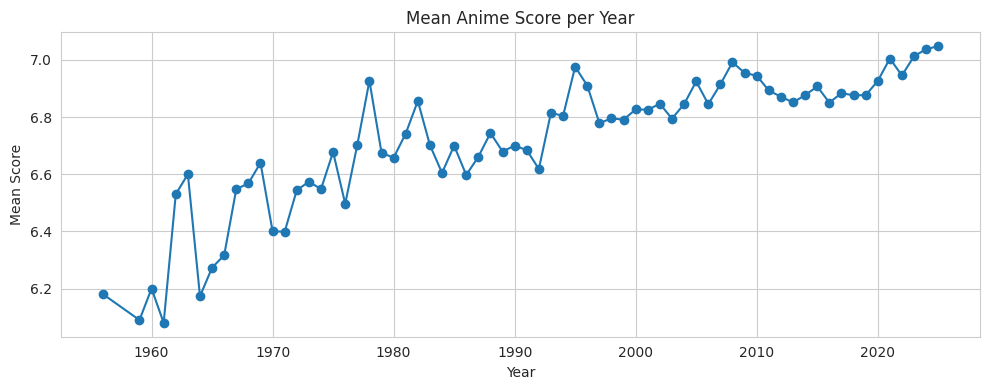

,Score
Year,
1956.0,6.180000
1959.0,6.090000
1960.0,6.200000
1961.0,6.080000
1962.0,6.530000
...,...
2021.0,7.004557
2022.0,6.945387
2023.0,7.012764


In [ ]:
def yearly_mean_score(df: pd.DataFrame) -> pd.DataFrame:
    """Compute and plot mean score per release year."""
    temp = df.copy()
    temp["Year"] = temp["Start_Date"].astype(str).str.extract(r"(\d{4})")
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

    yearly = temp.groupby("Year")["Score"].mean().dropna()
    plt.figure(figsize=(10, 4))
    plt.plot(yearly.index, yearly.values, marker="o")
    plt.title("Mean Anime Score per Year")
    plt.xlabel("Year")
    plt.ylabel("Mean Score")
    plt.tight_layout()
    plt.show()
    return yearly

yearly_mean_score(df)


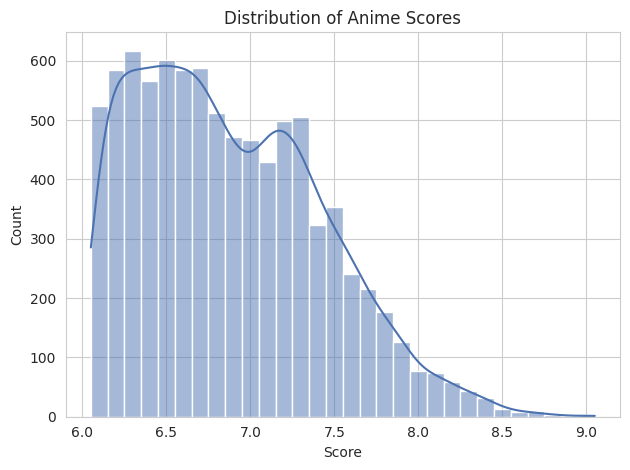

In [ ]:
def plot_score_distribution(df: pd.DataFrame) -> None:
    """Plot distribution of anime scores."""
    plt.figure()
    sns.histplot(df["Score"].dropna(), bins=30, kde=True, color="#4c72b0")
    plt.title("Distribution of Anime Scores")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_score_distribution(df)


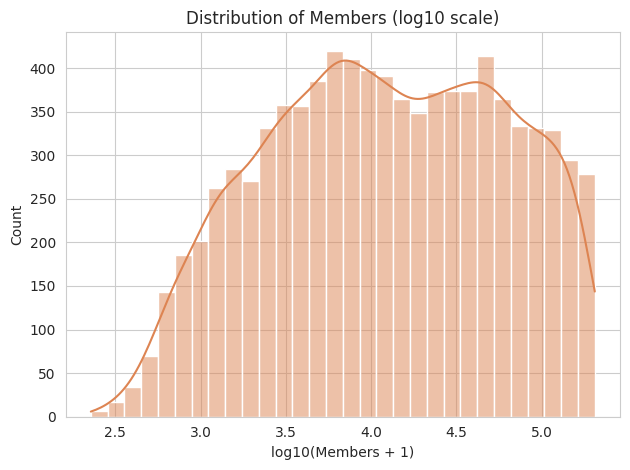

In [ ]:
def plot_members_distribution(df: pd.DataFrame) -> None:
    """Plot distribution of member counts on log scale."""
    members = df["Members"].dropna()
    plt.figure()
    sns.histplot(np.log10(members + 1), bins=30, kde=True, color="#dd8452")
    plt.title("Distribution of Members (log10 scale)")
    plt.xlabel("log10(Members + 1)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_members_distribution(df_clean)


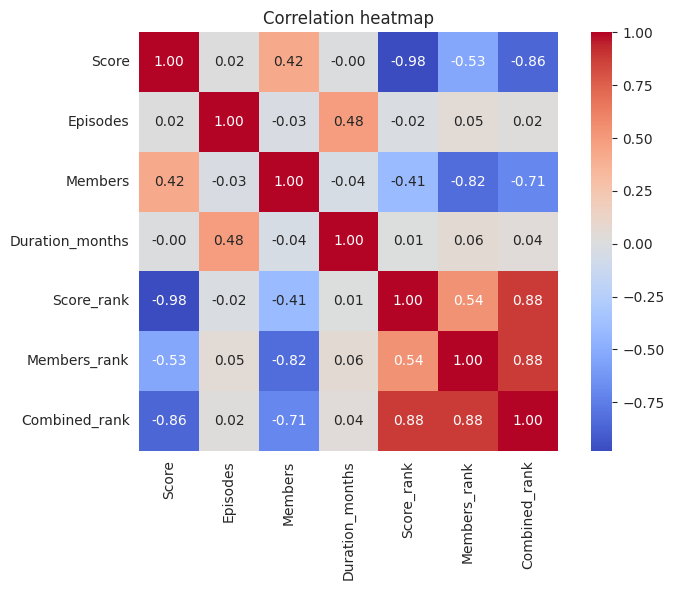

In [ ]:
# ----- 6. Корреляция матрицасы -----
def plot_corr_heatmap(df: pd.DataFrame) -> None:
    """Plot correlation heatmap for numeric columns."""
    num_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[num_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(df_clean)

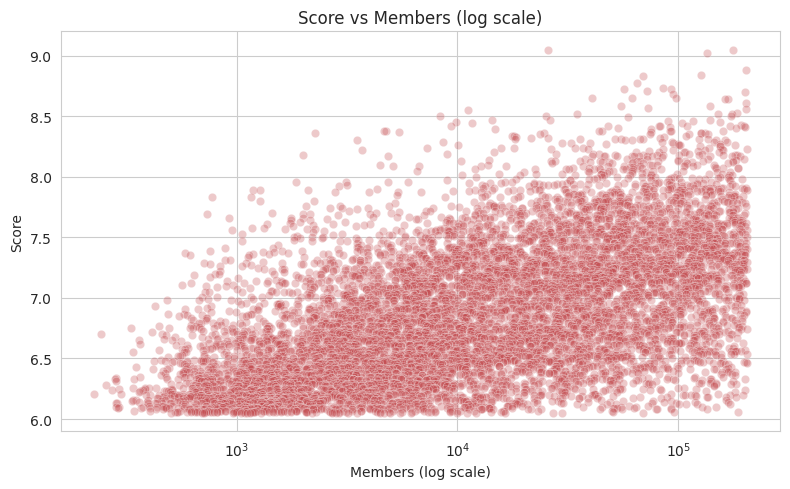

In [ ]:
def plot_members_vs_score(df: pd.DataFrame) -> None:
    """Scatter plot of members vs score with log scale on x-axis."""
    temp = df.dropna(subset=["Members", "Score"]).copy()
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=temp, x="Members", y="Score",
                    alpha=0.3, color="#c44e52")
    plt.xscale("log")
    plt.title("Score vs Members (log scale)")
    plt.xlabel("Members (log scale)")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

plot_members_vs_score(df)


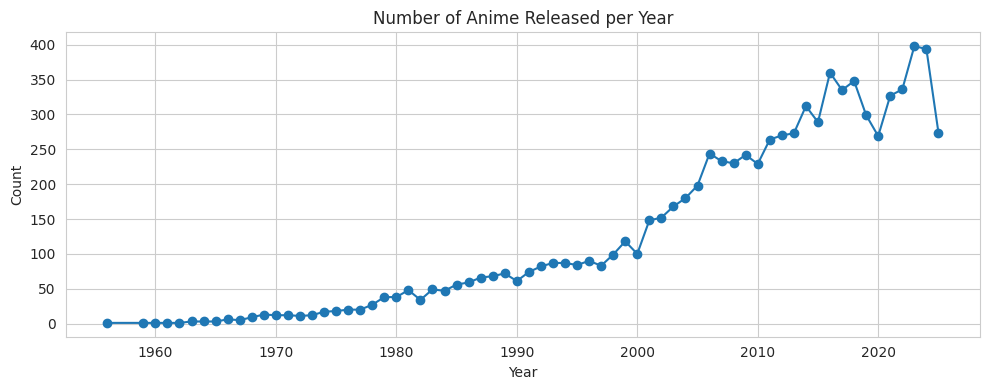

In [ ]:
def plot_anime_per_year(df: pd.DataFrame) -> None:
    """Plot number of anime released per year."""
    temp = df.copy()
    temp["Year"] = temp["Start_Date"].astype(str).str.extract(r"(\d{4})")
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")
    year_counts = temp["Year"].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    plt.plot(year_counts.index, year_counts.values, marker="o")
    plt.title("Number of Anime Released per Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_anime_per_year(df_clean)

In [ ]:
type_stats = type_group_stats(df)  # алдыңғы жауаптағы функция
display(type_stats)


,count,mean_score,median_score,mean_members,median_members
Type,,,,,
Movie,1567,6.975265,6.95,28325.280153,9104.0
TV,3282,6.896264,6.83,50626.776051,28290.0
ONA,1312,6.858895,6.74,15362.811738,3344.5
OVA,1136,6.853565,6.78,29681.488556,13860.5
Special,987,6.773597,6.70,23773.689970,10658.0
TV Special,419,6.748568,6.66,20193.601432,7628.0


Loading data from existing CSV file: 'Anime_top_10000.csv'


/tmp/ipython-input-3531034529.py:187: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ep.groupby("Ep_group")["Score"]


,count,mean,median,min,max
Ep_group,,,,,
1-12,6573,6.87,6.79,6.05,9.05
13-26,1033,6.94,6.92,6.05,8.84
27-52,797,6.86,6.80,6.05,8.77
53+,297,6.87,6.78,6.05,8.44


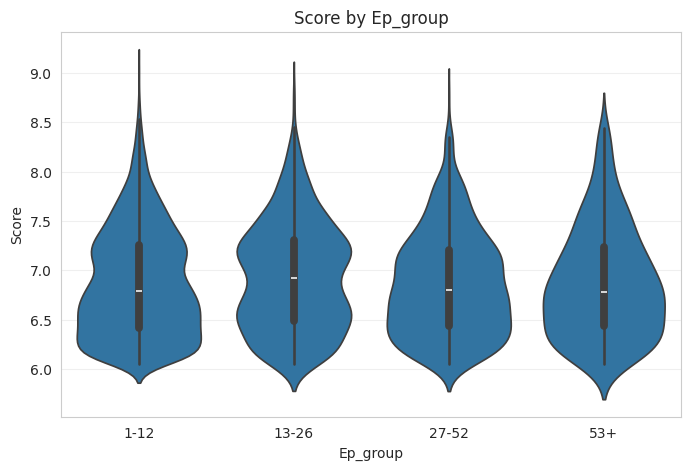

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import time
import os

sns.set_style("whitegrid")

# ===================== 1. ЗАГРУЗКА / МИНИМАЛЬНЫЙ СКРАПИНГ =====================

filename = "Anime_top_10000.csv"

if os.path.exists(filename):
    print(f"Loading data from existing CSV file: '{filename}'")
    df = pd.read_csv(filename)
else:
    print(f"CSV file '{filename}' not found. Performing minimal scraping to generate data.")
    titles = []
    scores = []
    anime_type_list = []
    episodes_list = []
    start_date_list = []
    end_date_list = []
    members_list = []
    headers = {"User-Agent": "Mozilla/5.0"}

    # Для примера берём только первые 50 записей,
    # для полного проекта можно расширить диапазон.
    for limit in range(0, 50, 50):
        url = f"https://myanimelist.net/topanime.php?limit={limit}&ajax=1"
        r = requests.get(url, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")
        rows = soup.find_all("tr", class_="ranking-list")

        if not rows:
            print("No data rows found during minimal scrape. Exiting scraping process.")
            break

        for row in rows:
            # Title
            title = row.find("h3").text.strip()
            titles.append(title)

            # Score
            score_tag = row.select_one("td.score span")
            scores.append(score_tag.text.strip() if score_tag else "N/A")

            # Info block
            info = row.find("div", class_="information")
            if info:
                lines = [l.strip() for l in info.text.split("\n") if l.strip()]
            else:
                lines = ["N/A", "N/A", "N/A"]

            # Type & Episodes
            type_ep = lines[0] if len(lines) > 0 else "N/A"
            if "(" in type_ep:
                anime_type = type_ep.split("(")[0].strip()
                eps = (
                    type_ep.split("(")[1]
                    .replace("eps)", "")
                    .replace("ep)", "")
                    .strip()
                )
            else:
                anime_type = type_ep
                eps = "N/A"
            anime_type_list.append(anime_type)
            episodes_list.append(eps)

            # Dates
            date_line = lines[1] if len(lines) > 1 else "N/A"
            date_parts = [part.strip() for part in date_line.split(" - ")]
            current_start_date = "N/A"
            current_end_date = "N/A"
            if len(date_parts) == 2:
                current_start_date = date_parts[0]
                current_end_date = date_parts[1]
            elif len(date_parts) == 1:
                current_start_date = date_parts[0]
                current_end_date = "Ongoing"
            start_date_list.append(current_start_date)
            end_date_list.append(current_end_date)

            # Members (строка вида "1,234,567 members")
            members_line = lines[2] if len(lines) > 2 else "N/A"
            members_list.append(members_line)

    df = pd.DataFrame(
        {
            "Title": titles,
            "Score": scores,
            "Type": anime_type_list,
            "Episodes": episodes_list,
            "Start_Date": start_date_list,
            "End_Date": end_date_list,
            "Members": members_list,
        }
    )
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Minimal data scraped and saved ({len(df)} records) to '{filename}'.")

# ===================== 2. БАЗОВАЯ ОЧИСТКА df =====================

# Score → число
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# Episodes → число
df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")

# Members: надёжная цепочка строковых операций + to_numeric
df["Members"] = (
    df["Members"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" members", "", regex=False)
)
df["Members"] = pd.to_numeric(df["Members"], errors="coerce")

# Даты
df["Start_Date"] = pd.to_datetime(df["Start_Date"], format="%b %Y", errors="coerce")
df["End_Date"] = pd.to_datetime(df["End_Date"], format="%b %Y", errors="coerce")

# Очистка текста в Title
def clean_text(text):
    if pd.isna(text):
        return text
    text = text.strip().lower()
    text = BeautifulSoup(text, "lxml").get_text()
    text = text.replace("\n", " ").replace("\t", " ").replace("  ", " ")
    return text

df["Title"] = df["Title"].apply(clean_text)

# Удаление выбросов по Members (IQR)
Q1 = df["Members"].quantile(0.25)
Q3 = df["Members"].quantile(0.75)
IQR = Q3 - Q1
df = df[
    (df["Members"] >= Q1 - 1.5 * IQR)
    & (df["Members"] <= Q3 + 1.5 * IQR)
]

# ===================== 3. df_clean: ЗАПОЛНЕНИЕ ПРОПУСКОВ + НОВЫЕ ПРИЗНАКИ =====================

df_clean = df.copy()

# Score: заполнить средним
df_clean["Score"] = df_clean["Score"].fillna(df_clean["Score"].mean())

# Episodes: NaN → 12 (по умолчанию)
df_clean["Episodes"] = df_clean["Episodes"].fillna(12)

# Заполнить End_Date сегодняшней датой, если пусто
today = pd.Timestamp.today()
df_clean.loc[df_clean["End_Date"].isna(), "End_Date"] = today

# Duration_months
df_clean["Duration_months"] = (
    (df_clean["End_Date"].dt.year - df_clean["Start_Date"].dt.year) * 12
    + (df_clean["End_Date"].dt.month - df_clean["Start_Date"].dt.month)
)

# Категории по Score
df_clean["Score_group"] = pd.cut(
    df_clean["Score"],
    bins=[0, 7, 8, 9, 10],
    labels=["Low", "Medium", "High", "Top"],
)

# ===================== 4. ГРУППЫ ПО ЭПИЗОДАМ + ВИОЛИН-ГРАФИК =====================

def add_episode_group(df_in):
    df_ep = df_in.copy()
    df_ep["Ep_group"] = pd.cut(
        df_ep["Episodes"],
        bins=[0, 13, 26, 52, 1000],
        labels=["1-12", "13-26", "27-52", "53+"]
    )
    return df_ep

def ep_group_stats(df_ep):
    return (
        df_ep.groupby("Ep_group")["Score"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )

def plot_violin(df_ep, x_col, y_col):
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df_ep, x=x_col, y=y_col, inner="box")
    plt.title(f"{y_col} by {x_col}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

# создаём группировки и выводим статистику + график
df_ep = add_episode_group(df_clean)
display(ep_group_stats(df_ep))
plot_violin(df_ep, "Ep_group", "Score")


Pearson r (Score ~ Members): 0.4245
p-value: 0


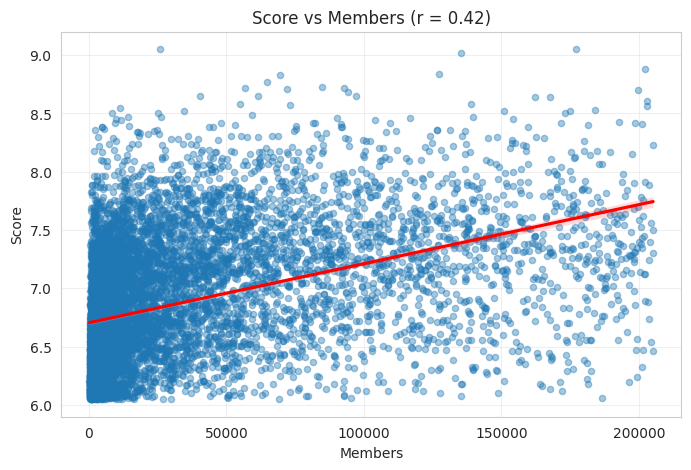

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def score_members_correlation(df_in):
    """
    Корреляция Пирсона между Score и Members + регрессионный график.
    """
    tmp = df_in[['Score', 'Members']].dropna()

    # Pearson r
    r, p = pearsonr(tmp['Score'], tmp['Members'])
    print(f"Pearson r (Score ~ Members): {r:.4f}")
    print(f"p-value: {p:.4g}")

    # Регрессионный график
    plt.figure(figsize=(8, 5))
    sns.regplot(data=tmp, x='Members', y='Score',
                scatter_kws={'alpha': 0.4, 's': 20},
                line_kws={'color': 'red'})
    plt.title(f'Score vs Members (r = {r:.2f})')
    plt.xlabel('Members')
    plt.ylabel('Score')
    plt.grid(True, alpha=0.3)
    plt.show()

# после этого в отдельной ячейке:
score_members_correlation(df_clean)  # или df


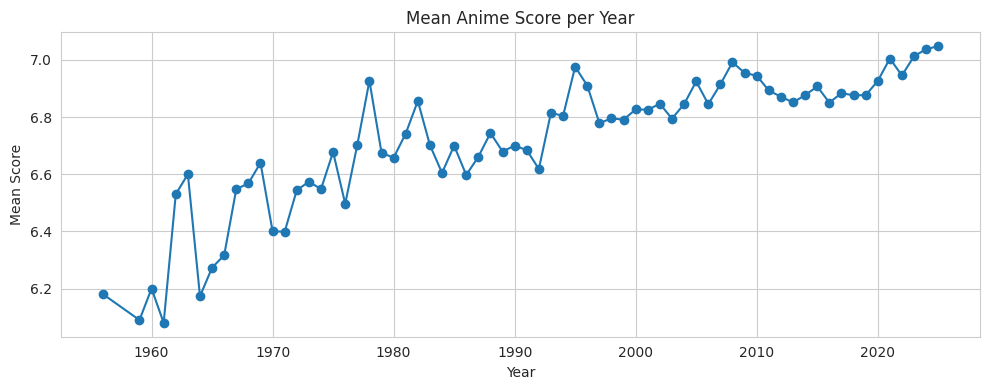

,Score
Year,
2021.0,7.004557
2022.0,6.945387
2023.0,7.012764
2024.0,7.037462
2025.0,7.047883


In [ ]:
yearly_scores = yearly_mean_score(df)
yearly_scores.tail()  # соңғы жылдарды көру

In [ ]:
def hidden_gems(df: pd.DataFrame,
                min_score: float = 8.5,
                max_members: int = 50000,
                n: int = 15) -> pd.DataFrame:
    """Find high-score, low-popularity anime."""
    temp = df.copy()
    gems = temp[(temp["Score"] >= min_score) & (temp["Members"] <= max_members)]
    return gems.sort_values("Score", ascending=False)[
        ["Title", "Type", "Score", "Members"]
    ].head(n)

hidden_gems(df)


,Title,Type,Score,Members
5,kingdom 6th season,TV,9.05,25769
78,uma musume: pretty derby - shin jidai no tobira,Movie,8.65,40493
130,doupo cangqiong: san nian zhi yue,ONA,8.55,11183
142,uma musume: cinderella gray part 2,TV,8.52,34663
151,nezha zhi mo tong nao hai,Movie,8.50,8322
153,shoujo☆kageki revue starlight movie,Movie,8.50,25134


In [ ]:
from google.colab import files

# Скачать сырой датасет (если нужен)
files.download("Anime_top_10000.csv")

# Скачать очищенный датасет
files.download("Anime_top_10000_clean.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>